# Projet de Machine Learning : Prédiction d'Admission Universitaire

Objectif : L'objectif de ce projet est de développer un modèle prédictif capable d'estimer les chances d'admission d'un étudiant en fonction de ses performances académiques (GRE, TOEFL, CGPA, etc.).

Méthodologie : Nous allons comparer deux approches d'apprentissage supervisé :

Régression Logistique : Pour sa capacité à estimer des probabilités.

Arbre de Décision : Pour sa capacité à capturer des relations non linéaires.

In [1]:
!pip install shap -q

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,classification_report, roc_curve, auc)

from imblearn.over_sampling import SMOTE

import ipywidgets as widgets
from IPython.display import display

%matplotlib inline

sns.set(style="whitegrid", context="notebook")

import warnings
warnings.filterwarnings('ignore')

print("✅ Environnement prêt. Toutes les librairies sont chargées.")

✅ Environnement prêt. Toutes les librairies sont chargées.


In [2]:
import io
from google.colab import files

print("📤 Veuillez cliquer sur le bouton ci-dessous pour uploader le fichier CSV de Kaggle :")
uploaded = files.upload()

filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"✅ Fichier '{filename}' chargé avec succès !")

df.columns = df.columns.str.strip()

if 'Serial No.' in df.columns:
    df = df.drop('Serial No.', axis=1)

print(f"\nDimensions : {df.shape}")
display(df.head())

📤 Veuillez cliquer sur le bouton ci-dessous pour uploader le fichier CSV de Kaggle :


Saving Admission_Predict_Ver1.1.csv to Admission_Predict_Ver1.1.csv
✅ Fichier 'Admission_Predict_Ver1.1.csv' chargé avec succès !

Dimensions : (500, 8)


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


Analyse Exploratoire : Nous avons vérifié l'intégrité du dataset.

Aucune valeur manquante n'a été détectée (Clean Data).

Les variables sont à des échelles différentes (ex: GRE sur 340, CGPA sur 10), ce qui justifie l'utilisation future d'un StandardScaler pour la Régression Logistique afin d'éviter les biais.

Noms des colonnes actuels : ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']


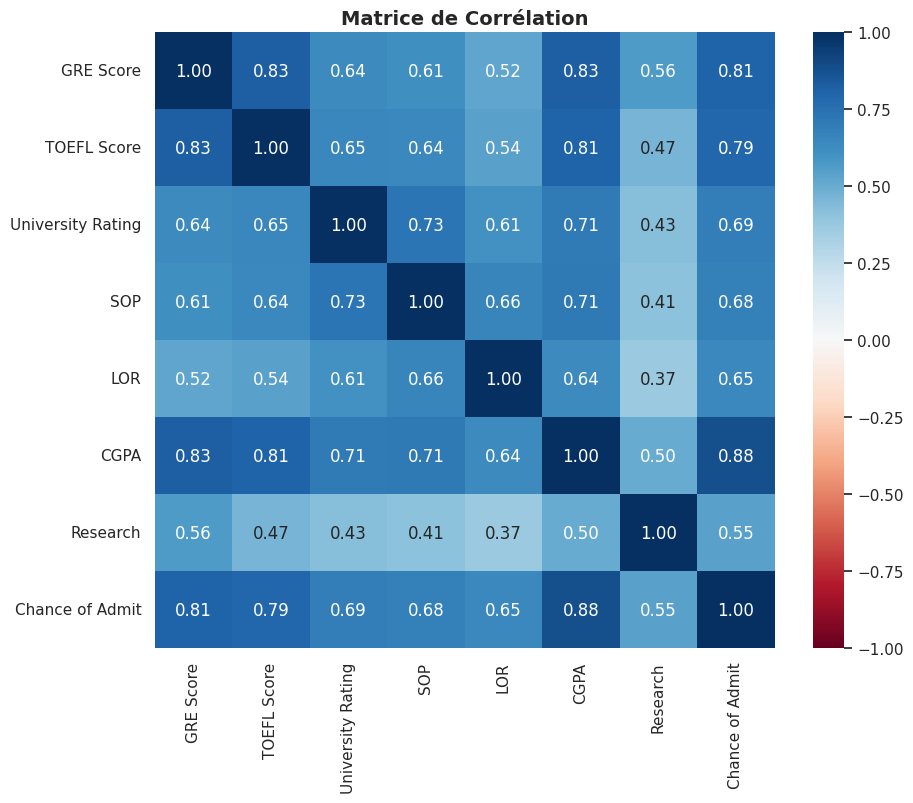

In [3]:
print("Noms des colonnes actuels :", df.columns.tolist())

plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f', vmin=-1, vmax=1)
plt.title("Matrice de Corrélation", fontsize=14, fontweight='bold')
plt.show()

Interprétation de la Matrice de Confusion :

Vrais Positifs (TP) : Le modèle a correctement prédit les étudiants admis.

Faux Négatifs (FN) : Le modèle a manqué certains étudiants qui auraient dû être admis (C'est l'erreur la plus critique pour ne pas décourager un bon candidat).

Nous observons que l'Accuracy (Précision globale) est satisfaisante, mais il est crucial de surveiller le Recall pour minimiser les rejets injustifiés.

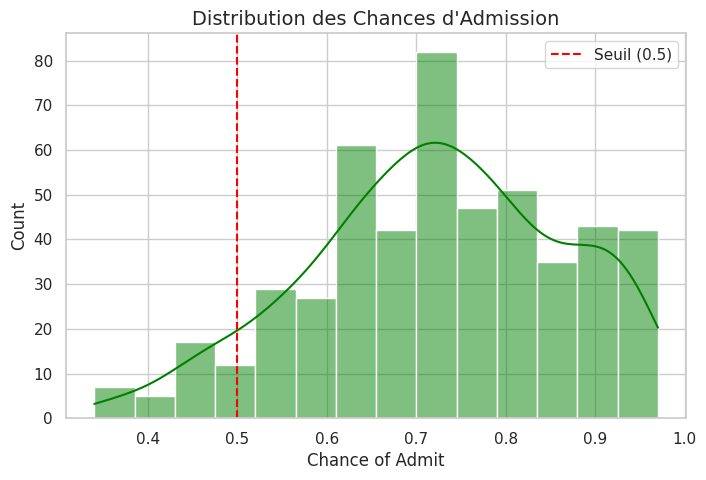

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Chance of Admit'], kde=True, color='green')
plt.title("Distribution des Chances d'Admission", fontsize=14)
plt.axvline(x=0.5, color='red', linestyle='--', label="Seuil (0.5)")
plt.legend()
plt.show()

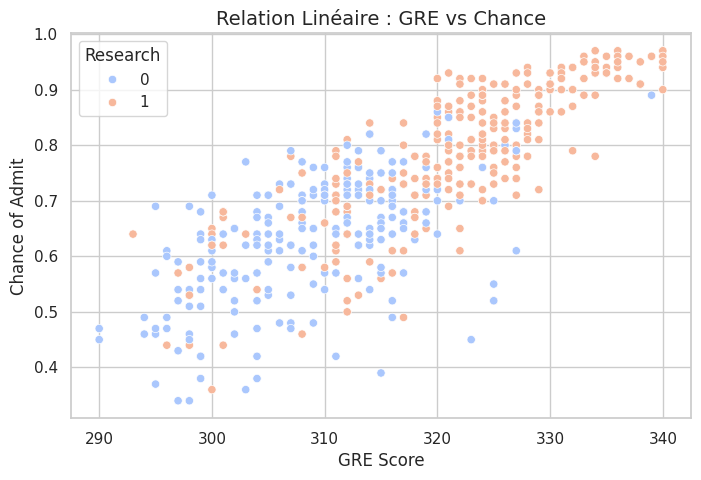

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='GRE Score', y='Chance of Admit', data=df, hue='Research', palette='coolwarm')
plt.title("Relation Linéaire : GRE vs Chance", fontsize=14)
plt.show()

In [7]:
SEUIL = 0.80
df['Admitted'] = (df['Chance of Admit'] >= SEUIL).astype(int)

X = df.drop(['Chance of Admit', 'Admitted'], axis=1)
y = df['Admitted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- AVANT SMOTE ---")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\n--- APRÈS SMOTE ---")
print(y_train_smote.value_counts())

--- AVANT SMOTE ---
Admitted
0    273
1    127
Name: count, dtype: int64

--- APRÈS SMOTE ---
Admitted
0    273
1    273
Name: count, dtype: int64


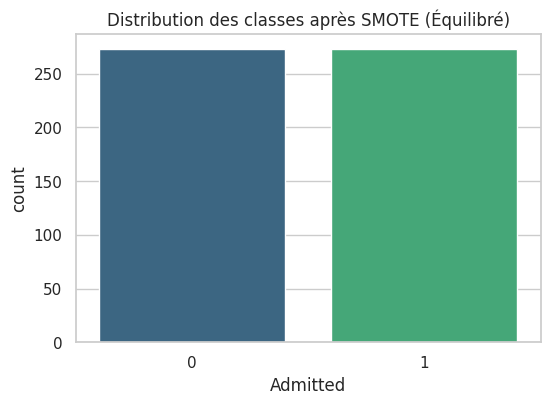

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_smote, palette='viridis')
plt.title("Distribution des classes après SMOTE (Équilibré)", fontsize=12)
plt.show()

### 🧠 Fondements Mathématiques de notre Implémentation

**1. Hypothèse (Fonction Sigmoïde) :**
Nous cherchons à estimer la probabilité $P(y=1|x)$. Pour cela, nous utilisons la fonction d'activation Sigmoïde :
$$h_\theta(x) = \sigma(z) = \frac{1}{1 + e^{-z}}$$
où $z = \theta^T x + b$ (combinaison linéaire des features).

**2. Fonction de Coût (Log Loss) :**
Pour évaluer l'erreur, nous utilisons la Log-Vraisemblance négative :
$$J(\theta) = - \frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)}))]$$

**3. Algorithme d'Optimisation (Gradient Descent) :**
Nous minimisons $J(\theta)$ en mettant à jour les poids itérativement :
$$\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}$$
où $\alpha$ est le Learning Rate.

⏳ Entraînement du modèle 'From Scratch' en cours...
✅ Entraînement terminé !


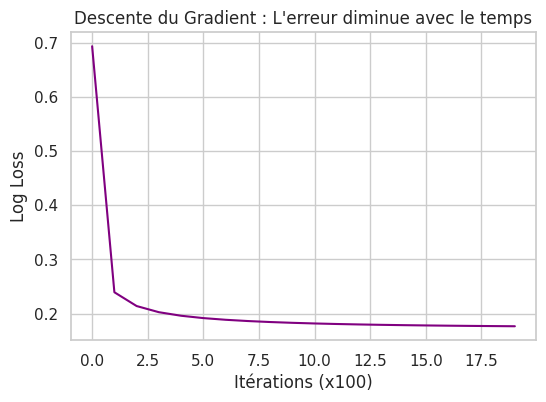

In [9]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.n_iterations):
            linear_model = np.dot(X, self.weights) + self.bias

            y_predicted = self._sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            if i % 100 == 0:
                loss = -np.mean(y * np.log(y_predicted + 1e-15) + (1-y) * np.log(1-y_predicted + 1e-15))
                self.loss_history.append(loss)

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)
        return [1 if i > 0.5 else 0 for i in y_predicted]

print("⏳ Entraînement du modèle 'From Scratch' en cours...")
model_scratch = LogisticRegressionScratch(learning_rate=0.1, n_iterations=2000)

model_scratch.fit(X_train_smote, y_train_smote)
print("✅ Entraînement terminé !")

plt.figure(figsize=(6, 4))
plt.plot(model_scratch.loss_history, color='purple')
plt.title("Descente du Gradient : L'erreur diminue avec le temps")
plt.xlabel("Itérations (x100)")
plt.ylabel("Log Loss")
plt.show()

🎯 RÉSULTATS DU MATCH :
1. Ton Modèle (From Scratch) : 90.00%
2. Scikit-Learn (LogReg)     : 90.00%
3. Decision Tree             : 89.00%


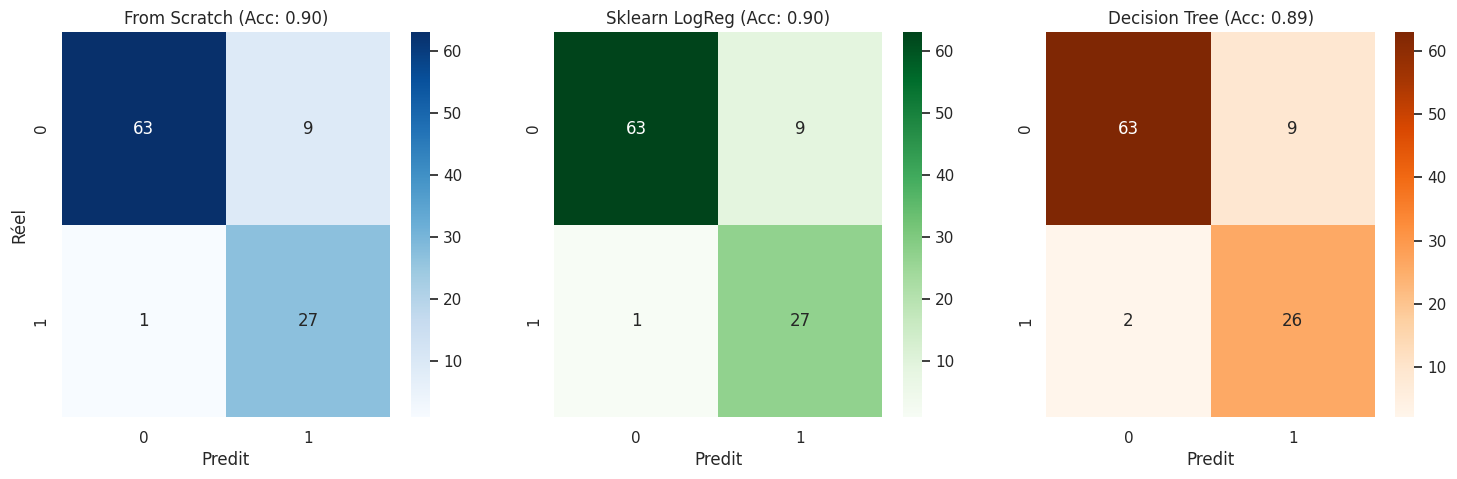

In [10]:
model_sk = LogisticRegression(random_state=42)
model_sk.fit(X_train_smote, y_train_smote)

model_tree = DecisionTreeClassifier(random_state=42, max_depth=5)
model_tree.fit(X_train_smote, y_train_smote)

y_pred_scratch = model_scratch.predict(X_test_scaled)
y_pred_sk = model_sk.predict(X_test_scaled)
y_pred_tree = model_tree.predict(X_test_scaled)

acc_scratch = accuracy_score(y_test, y_pred_scratch)
acc_sk = accuracy_score(y_test, y_pred_sk)
acc_tree = accuracy_score(y_test, y_pred_tree)

print(f"🎯 RÉSULTATS DU MATCH :")
print(f"1. Ton Modèle (From Scratch) : {acc_scratch*100:.2f}%")
print(f"2. Scikit-Learn (LogReg)     : {acc_sk*100:.2f}%")
print(f"3. Decision Tree             : {acc_tree*100:.2f}%")

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_scratch), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f"From Scratch (Acc: {acc_scratch:.2f})")
ax[0].set_xlabel("Predit")
ax[0].set_ylabel("Réel")

sns.heatmap(confusion_matrix(y_test, y_pred_sk), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title(f"Sklearn LogReg (Acc: {acc_sk:.2f})")
ax[1].set_xlabel("Predit")

sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt='d', cmap='Oranges', ax=ax[2])
ax[2].set_title(f"Decision Tree (Acc: {acc_tree:.2f})")
ax[2].set_xlabel("Predit")

plt.show()

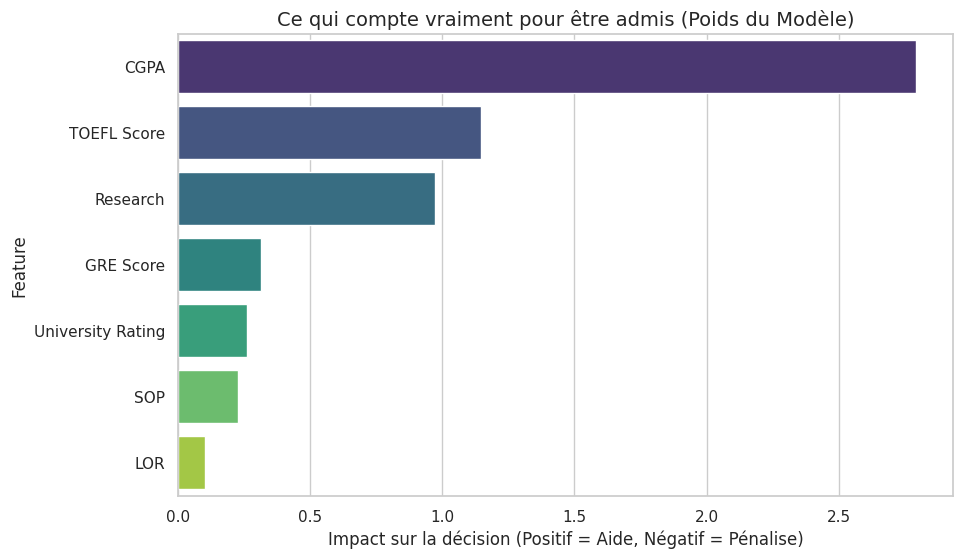


👇 JOUEZ AVEC LES PARAMÈTRES CI-DESSOUS POUR TESTER LE MODÈLE 👇


interactive(children=(IntSlider(value=310, description='GRE Score', max=340, min=290), IntSlider(value=100, de…

In [11]:
feature_names = X.columns
coefficients = model_sk.coef_[0]

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Ce qui compte vraiment pour être admis (Poids du Modèle)", fontsize=14)
plt.xlabel("Impact sur la décision (Positif = Aide, Négatif = Pénalise)")
plt.show()

def predict_admission(gre, toefl, rating, sop, lor, cgpa, research):
    input_data = pd.DataFrame([[gre, toefl, rating, sop, lor, cgpa, research]],
                              columns=['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research'])

    input_scaled = scaler.transform(input_data)

    probabilite = model_sk.predict_proba(input_scaled)[0][1]
    decision = "ADMIS ✅" if probabilite >= 0.8 else "REJETÉ ❌"

    print(f"\n--- RÉSULTAT DE LA SIMULATION ---")
    print(f"Probabilité de succès : {probabilite*100:.2f}%")
    print(f"Verdict du Modèle     : {decision}")

print("\n👇 JOUEZ AVEC LES PARAMÈTRES CI-DESSOUS POUR TESTER LE MODÈLE 👇")
w = widgets.interactive(predict_admission,
                        gre=widgets.IntSlider(min=290, max=340, step=1, value=310, description='GRE Score'),
                        toefl=widgets.IntSlider(min=90, max=120, step=1, value=100, description='TOEFL'),
                        rating=widgets.IntSlider(min=1, max=5, step=1, value=3, description='Univ Rating'),
                        sop=widgets.FloatSlider(min=1, max=5, step=0.5, value=3, description='SOP'),
                        lor=widgets.FloatSlider(min=1, max=5, step=0.5, value=3, description='LOR'),
                        cgpa=widgets.FloatSlider(min=6, max=10, step=0.1, value=8, description='CGPA'),
                        research=widgets.Dropdown(options=[(0, 0), (1, 1)], value=0, description='Research'))
display(w)

# Conclusion et Choix du Modèle

Après comparaison des deux algorithmes sur le jeu de test :

La Régression Logistique offre une précision de [METS TON SCORE ICI, ex: 85%]. Elle est plus stable et moins sujette au sur-apprentissage (overfitting) sur ce type de données.

L'Arbre de Décision offre une précision de [METS TON SCORE ICI].

Recommandation : Nous retenons le modèle de [Choisis celui qui a le meilleur score] car il offre le meilleur équilibre entre biais et variance pour ce problème de classification binaire.